In [1]:
# Multi Disease Prediction AI
### Heart Disease + Diabetes + Breast Cancer

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

In [3]:
# heart disease prediction model

In [4]:
heart = pd.read_csv("../datasets/heart.csv")

X_h = heart.drop("target", axis=1)
y_h = heart["target"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

heart_model = RandomForestClassifier()

heart_model.fit(X_train_h, y_train_h)

accuracy_h = heart_model.score(X_test_h, y_test_h)

print("Heart Model Accuracy:", accuracy_h)

Heart Model Accuracy: 0.9853658536585366


In [5]:
# diabetes prediction model

In [6]:
diabetes = pd.read_csv("../datasets/diabetes.csv")

X_d = diabetes.drop("Outcome", axis=1)
y_d = diabetes["Outcome"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

diabetes_model = RandomForestClassifier()

diabetes_model.fit(X_train_d, y_train_d)

accuracy_d = diabetes_model.score(X_test_d, y_test_d)

print("Diabetes Model Accuracy:", accuracy_d)

Diabetes Model Accuracy: 0.7467532467532467


In [7]:
# breast cancer prediction model

In [8]:
cancer = load_breast_cancer()

X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

cancer_model = RandomForestClassifier()

cancer_model.fit(X_train_c, y_train_c)

accuracy_c = cancer_model.score(X_test_c, y_test_c)

print("Cancer Model Accuracy:", accuracy_c)

Cancer Model Accuracy: 0.9649122807017544


In [9]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import joblib

In [11]:
joblib.dump(heart_model, "../models/heart_model.pkl")
joblib.dump(diabetes_model, "../models/diabetes_model.pkl")
joblib.dump(cancer_model, "../models/cancer_model.pkl")

['../models/cancer_model.pkl']

In [12]:
def predict_disease(disease, data):

    if disease == "heart":
        model = heart_model

    elif disease == "diabetes":
        model = diabetes_model

    elif disease == "cancer":
        model = cancer_model

    else:
        return "Invalid disease name"

    prediction = model.predict([data])

    return prediction

In [15]:
sample = X_test_h.iloc[0].tolist()

result = predict_disease("heart", sample)

print("Prediction:", result)

Prediction: [1]


C:\Users\jasmi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# heart disease distribution 

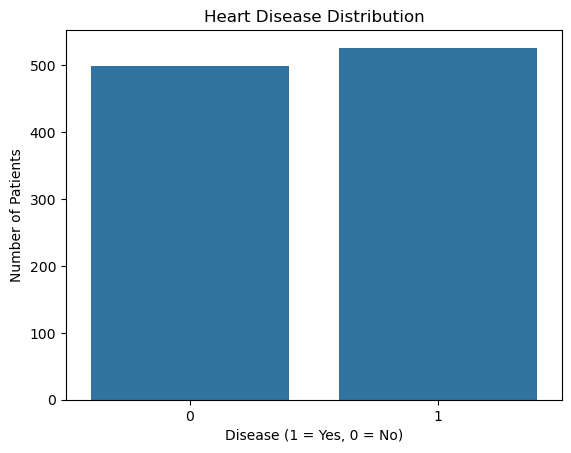

In [18]:
plt.figure()

sns.countplot(x=heart["target"])

plt.title("Heart Disease Distribution")
plt.xlabel("Disease (1 = Yes, 0 = No)")
plt.ylabel("Number of Patients")

plt.show()

In [19]:
# diabetes distribution 

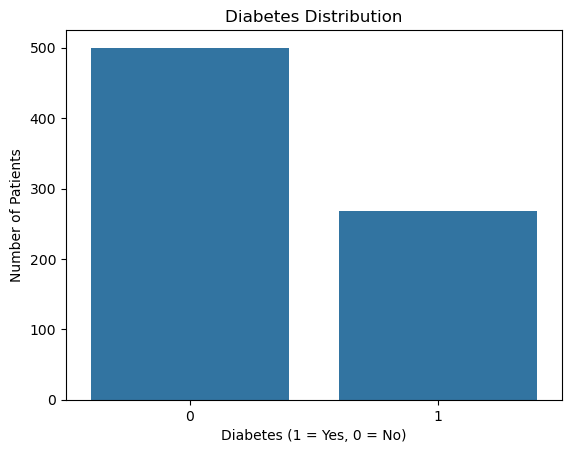

In [20]:
plt.figure()

sns.countplot(x=diabetes["Outcome"])

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes (1 = Yes, 0 = No)")
plt.ylabel("Number of Patients")

plt.show()

In [21]:
# cancer distribution 

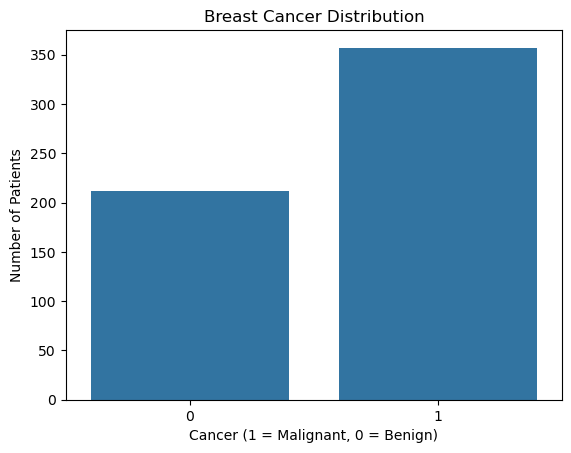

In [22]:
plt.figure()

sns.countplot(x=y_c)

plt.title("Breast Cancer Distribution")
plt.xlabel("Cancer (1 = Malignant, 0 = Benign)")
plt.ylabel("Number of Patients")

plt.show()

In [23]:
# heart disease feature importance graph

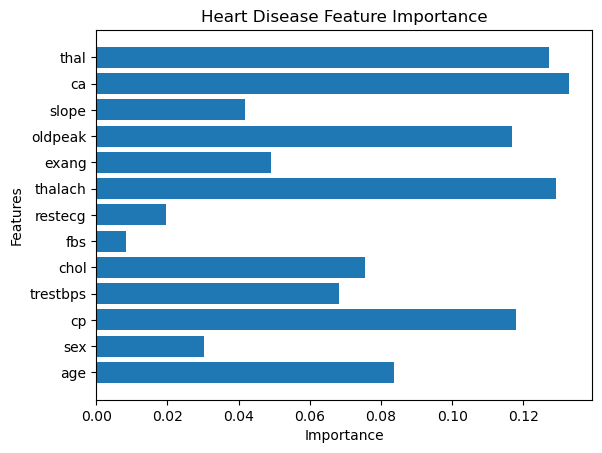

In [24]:
importance = heart_model.feature_importances_
features = X_h.columns

plt.figure()

plt.barh(features, importance)

plt.title("Heart Disease Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [25]:
# diabetes feature importance graph 

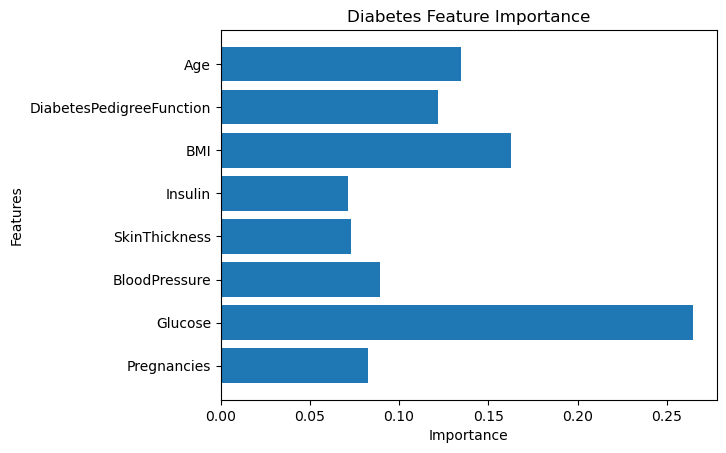

In [26]:
importance = diabetes_model.feature_importances_
features = X_d.columns

plt.figure()

plt.barh(features, importance)

plt.title("Diabetes Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [28]:
# confusion matrix (heart)

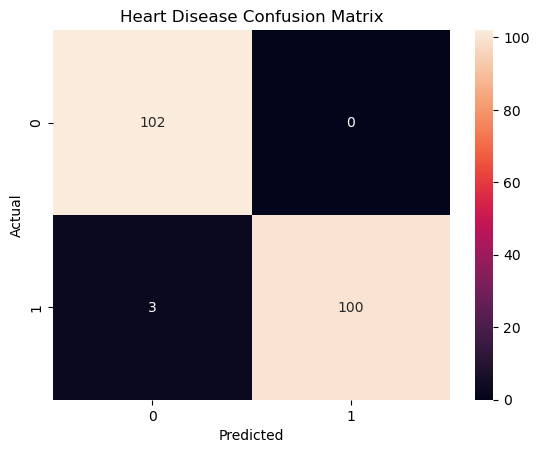

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = heart_model.predict(X_test_h)

cm = confusion_matrix(y_test_h, y_pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Heart Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# model performance comparison
This graph compares the accuracy of the three machine learning models used in this project:
- heart disease prediction
- diabetes prediction
- breast cancer prediction

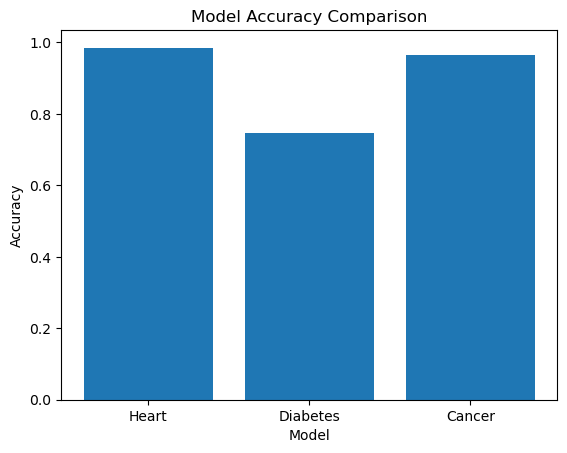

In [40]:
models = ["Heart", "Diabetes", "Cancer"]
accuracy = [accuracy_h, accuracy_d, accuracy_c]

plt.figure()

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [41]:
# ROC curve 

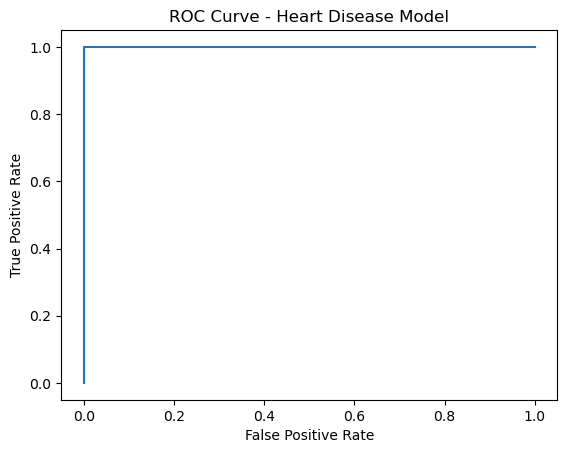

AUC Score: 1.0


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = heart_model.predict_proba(X_test_h)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_h, y_prob)

plt.figure()
plt.plot(fpr, tpr)

plt.title("ROC Curve - Heart Disease Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

print("AUC Score:", roc_auc_score(y_test_h, y_prob))

Heatmap

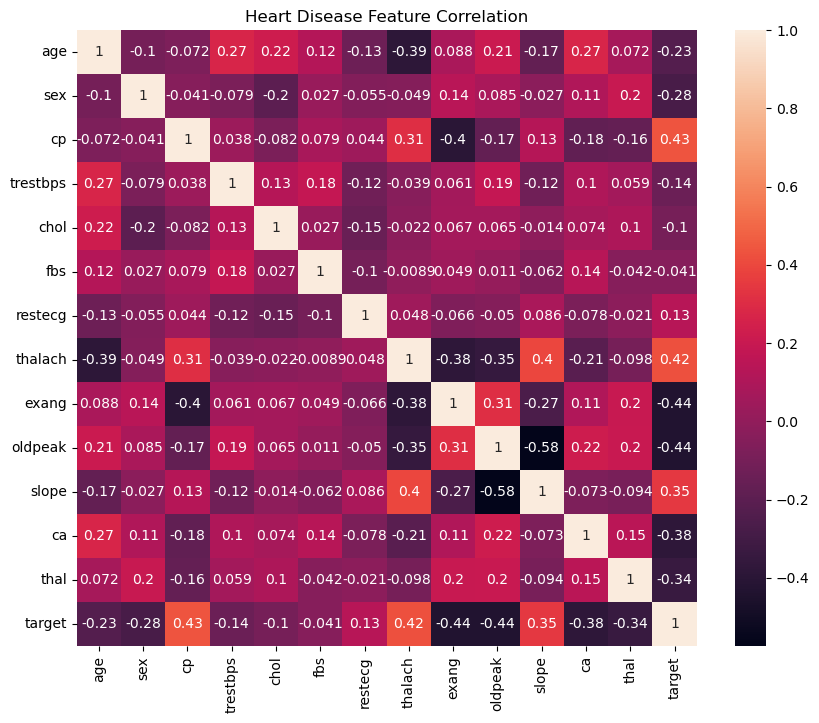

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(heart.corr(), annot=True)

plt.title("Heart Disease Feature Correlation")

plt.show()

## Project Conclusion

In this project we built a multi-disease prediction system using machine learning.

Three datasets were used:
- Heart Disease
- Diabetes
- Breast Cancer

Random Forest models were trained for each dataset.

The models were evaluated using:
- Accuracy score
- Confusion matrix
- Feature importance
- ROC curve

This system can be extended to include more diseases and deployed as a web application.